In [67]:
from h5py import File
import pickle
from matplotlib import pyplot as plt
import numpy as np

In [101]:
with open("valid_save.pkl", "rb") as f:
    save = pickle.load(f)

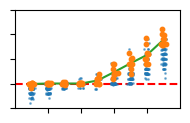

In [102]:
num_min = np.zeros((9, 10))
for i in range(9):
    for j in range(10):
        num_min[i, j] = save[i, j, :, 0][save[i, j, :, 1].argmin()]
num_all = save[:, :, :, 0].reshape(10, -1)
plt.figure(figsize=(2, 2/1.5))
for i in range(9):
    plt.scatter(np.random.normal(loc=(i+1)/10, scale=0.008, size=90), num_all[i] + np.random.normal(loc=0, scale=0.08, size=90), s=1, alpha=0.5, c="C0", zorder=3)
    plt.scatter(np.random.normal(loc=(i+1)/10, scale=0.008, size=10), num_min[i] + np.random.normal(loc=0, scale=0.08, size=10), s=10, marker="o", c="C1", zorder=4)
plt.plot(np.arange(1, 10)/10, num_min.mean(axis=1), c="C2", zorder=2)
plt.hlines(y=5, xmin=0, xmax=1, color="r", linestyle="--", zorder=1)
plt.xlim(0, 1)
plt.ylim(0, 20)
plt.yticks([0, 5, 10, 15, 20])
plt.xticks([0.2, 0.4, 0.6, 0.8])
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/figsA/figsAb1.png")

In [103]:
with open("save_benchmark.pkl", "rb") as f:
    save_benchmark = pickle.load(f)

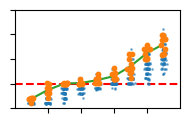

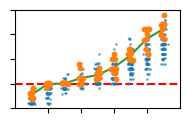

In [104]:
for ni in [2, 3]:
    save = save_benchmark[:, :, :, ni]
    num_min = np.zeros((9, 10))
    for i in range(9):
        for j in range(10):
            num_min[i, j] = save[i, j, :, 0][save[i, j, :, 1].argmin()]
    num_all = save[:, :, :, 0].reshape(10, -1)
    plt.figure(figsize=(2, 2/1.5))
    for i in range(9):
        plt.scatter(np.random.normal(loc=(i+1)/10, scale=0.008, size=90), num_all[i] + np.random.normal(loc=0, scale=0.08, size=90), s=1, alpha=0.5, c="C0", zorder=3)
        plt.scatter(np.random.normal(loc=(i+1)/10, scale=0.008, size=10), num_min[i] + np.random.normal(loc=0, scale=0.08, size=10), s=10, marker="o", c="C1", zorder=4)
    plt.plot(np.arange(1, 10)/10, num_min.mean(axis=1), c="C2", zorder=2)
    plt.hlines(y=5, xmin=0, xmax=1, color="r", linestyle="--", zorder=1)
    plt.xlim(0, 1)
    plt.ylim(0, 20)
    plt.yticks([0, 5, 10, 15, 20])
    plt.xticks([0.2, 0.4, 0.6, 0.8])
    plt.tick_params(labelleft=False, labelbottom=False)
    plt.tight_layout()
    plt.savefig("figures/figsA/figsAb{}.png".format(int((ni - 2) * 2)))
    plt.show()

In [14]:
diss = np.array(File("seqNMF/save_benchmark.mat")["DissSave"]).transpose(4, 3, 2, 1, 0)

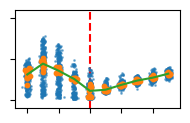

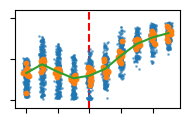

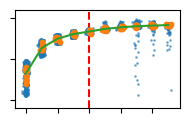

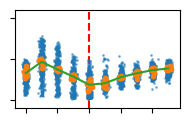

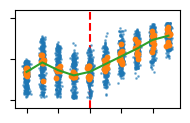

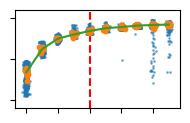

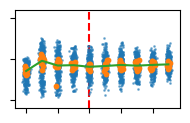

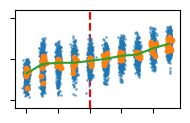

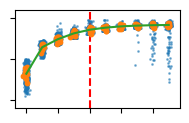

In [105]:
for ni in [0, 2, 4]:
    for li in [0, 2, 4]:
        plt.figure(figsize=(2, 2/1.5))
        plt.vlines(5, ymin=-0.1, ymax=1.1, color="r", zorder=-1, linestyle="--")
        for ki in range(10):
            plt.scatter(np.random.normal(loc=ki+1, scale=0.08, size=450), diss[ni, :, ki, li, :].reshape(-1), s=1, alpha=0.5, c="C0")
            plt.scatter(np.random.normal(loc=ki+1, scale=0.08, size=10), np.median(diss[ni, :, ki, li, :], axis=1), s=10, marker="o", c="C1")
        plt.plot(np.arange(1, 11), np.median(diss[ni, :, :, li, :], axis=-1).mean(axis=0), c="C2")
        plt.ylim(-0.1, 1.1)
        plt.yticks([0, 0.5, 1.0])
        plt.xticks([1, 3, 5, 7, 9])
        plt.tick_params(labelleft=False, labelbottom=False)
        plt.tight_layout()
        plt.savefig("figures/figsA/figsAc{}_{}.png".format(ni, li))
        plt.show()